# Spatial Copper Mining in DR Congo
# iii. Environmental Impact

**Spatial History of Copper Mining — Copperbelt (DRC/Zambia)**

Analyses environmental degradation signals around mining zones using:
- **Sentinel-2** → spectral indices (NDVI, NBR, NDWI)
- **MODIS MOD13Q1** → long-term vegetation trends (2000-2025)
- **SRTM DEM** → erosion proxies and drainage patterns

- Inputs:  `outputs/processed/mrds_features.gpkg`, `mrds_clusters.gpkg`, `districts_mine_counts.gpkg`
- Outputs: `outputs/processed/spectral_indices.tif`, `env_impact_zones.gpkg`, `drainage_network.gpkg`


### Set up and imports

In [2]:
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [3]:
from __future__ import annotations

import warnings
import sys
from pathlib import Path

import numpy as np
import geopandas as gpd
import xarray as xr
import rioxarray as rxr
from typing import Dict, Optional
from rasterio.crs import CRS

import matplotlib.pyplot as plt
from matplotlib.colors import LightSource
from matplotlib_scalebar.scalebar import ScaleBar

warnings.filterwarnings("ignore", category=UserWarning)
warnings.filterwarnings("ignore", category=FutureWarning)

PROJECT_ROOT = Path("..").resolve()
sys.path.append(str(PROJECT_ROOT / "src"))

from obtain_remote_data import (
    COPPERBELT_BBOX,
    CRS_PROJ,
    PROJECT_ROOT,
    DATA_RAW,
    DATA_PROCESSED,
    MAPS_OUT,
    FIGURES_OUT,
    load_sentinel_scene,
    load_srtm,
    build_modis_annual_composites,
)

from compute_data import (
    compute_spectral_indices,
    classify_ndvi,
    compute_ndvi_trend,
    vectorise_decline_zones,
    compute_slope,
    compute_twi,
    compute_roughness,
    extract_drainage_network,
    compute_impact_score,
    extract_zonal_stats,
    downsample_for_plot,
)

from mapstyle import add_map_furniture, PALETTE

DATA_PROCESSED_OUT = DATA_PROCESSED / "env_impact"
MAPS_OUT = MAPS_OUT / "env_impact"
FIGURES_OUT = FIGURES_OUT / "env_impact"

for d in [DATA_RAW, DATA_PROCESSED_OUT, MAPS_OUT, FIGURES_OUT]:
    d.mkdir(parents=True, exist_ok=True)

print("✓ Setup complete.")
print(f"  PROJECT_ROOT: {PROJECT_ROOT}")
print(f"  DATA_PROCESSED_OUT: {DATA_PROCESSED_OUT}")
print(f"  CRS_PROJ    : {CRS_PROJ}")
print(f"  COPPERBELT_BBOX: {COPPERBELT_BBOX}")

✓ Setup complete.
  PROJECT_ROOT: C:\Users\jlima\Documents\GitHub\spatial-history-cuco-mining
  DATA_PROCESSED_OUT: C:\Users\jlima\Documents\GitHub\spatial-history-cuco-mining\data\processed\env_impact
  CRS_PROJ    : EPSG:32735
  COPPERBELT_BBOX: [24.0, -13.7, 29.4, -10.0]


## Load inputs

#### · Mining layers (from notebook II)

In [5]:
def load_mining_layers(proc_dir: Path) -> tuple[gpd.GeoDataFrame, gpd.GeoDataFrame, gpd.GeoDataFrame]:
    """Load processed mining GeoPackages produced by notebook II."""
    mrds      = gpd.read_file(proc_dir / "mrds_features.gpkg")
    clusters  = gpd.read_file(proc_dir / "mrds_clusters.gpkg")
    districts = gpd.read_file(proc_dir / "districts_mine_counts.gpkg")

    # Ensure projected CRS
    mrds      = mrds.to_crs(CRS_PROJ)
    clusters  = clusters.to_crs(CRS_PROJ)
    districts = districts.to_crs(CRS_PROJ)

    print(f"  mrds:      {len(mrds):,} features")
    print(f"  clusters:  {len(clusters):,} clusters")
    print(f"  districts: {len(districts):,} districts")
    return mrds, clusters, districts


print("Loading mining layers...")
mrds, clusters, districts = load_mining_layers(DATA_PROCESSED / "mining_core")
print(f"  ✓ mrds_features.gpkg  ({list(mrds.columns)})")


Loading mining layers...
  mrds:      132 features
  clusters:  132 clusters
  districts: 44 districts
  ✓ mrds_features.gpkg  (['site_name', 'ore_map', 'dist_road_km', 'dist_water_km', 'dist_border_km', 'geometry'])


### · Sentinel-2 bands

Expected layout: `data/raw/sentinel/` contains pre-downloaded band GeoTIFFs (B04=Red, B08=NIR, B11=SWIR-1, B12=SWIR-2) clipped to `COPPERBELT_BBOX`.<br>

If running for the first time, download via `sentinelsat` or Copernicus Browser and place in `data/raw/sentinel/`.  The loader below accepts either a folder of single-band TIFs or a single multiband stack.


In [ ]:
ESSENTIAL_BANDS  = ["red", "nir", "swir16", "swir22"] # 665 nm, 842 nm, 1610 nm — used in NBR, 2190 nm — alternative SWIR

sentinel_bands = load_sentinel_scene(
    bbox=COPPERBELT_BBOX,
    start="2023-06-01T00:00:00Z",
    end="2023-08-31T23:59:59Z",
    bands=ESSENTIAL_BANDS,
    resolution=60,
    force_download=False
)

print(f"✓ Sentinel-2 bands loaded: {list(sentinel_bands.keys())}")

  Adaptive mosaic: 5x3 tiles (15 total)
  Tile 1/15...
  Tile 2/15...
  Tile 3/15...
 Process API failed (Response ended prematurely). Attempt 1/5. Retrying in 1s…
  Tile 4/15...
  Tile 5/15...
  Tile 6/15...
  Tile 7/15...
  Tile 8/15...
  Tile 9/15...
  Tile 10/15...
  Tile 11/15...
  Tile 12/15...
  Tile 13/15...
  Tile 14/15...
  Tile 15/15...
  Creating final mosaic for band: red
  Creating final mosaic for band: nir
  Creating final mosaic for band: swir16
  Creating final mosaic for band: swir22
✓ Sentinel-2 bands loaded: ['red', 'nir', 'swir16', 'swir22']


In [9]:
sentinel_bands = {
    b: da.rio.reproject("EPSG:32735")
    for b, da in sentinel_bands.items()
}

### · MODIS MOD13Q1 — vegetation index time series

- Uses `earthaccess` + `rioxarray` (pyhdf dependency).
- Product: **MOD13Q1** (250 m, 16-day NDVI composites).
- Full 2010-2025 retrieval is done in loops per year to keep granule counts manageable; results are cached as annual composites in `data/processed/modis/`.


In [10]:
MODIS_CACHE   = DATA_PROCESSED / "modis" / "annual_composites"
MODIS_CACHE.mkdir(parents=True, exist_ok=True)

MODIS_YEARS   = list(range(2010, 2026))
MODIS_PRODUCT = "modis-13Q1-061"        # collection ID in Planetary Computer
MODIS_BAND    = "250m_16_days_NDVI"     # asset name confirmed
MODIS_NODATA  = -3000                   # fill value of the product

modis_composites = build_modis_annual_composites()
print(f"  Available Composites: {sorted(modis_composites.keys())}")

  ✓ MODIS 2010: cache hit
  ✓ MODIS 2011: cache hit
  ✓ MODIS 2012: cache hit
  ✓ MODIS 2013: cache hit
  ✓ MODIS 2014: cache hit
  ✓ MODIS 2015: cache hit
  ✓ MODIS 2016: cache hit
  ✓ MODIS 2017: cache hit
  ✓ MODIS 2018: cache hit
  ✓ MODIS 2019: cache hit
  ✓ MODIS 2020: cache hit
  ✓ MODIS 2021: cache hit
  ✓ MODIS 2022: cache hit
  ✓ MODIS 2023: cache hit
  ✓ MODIS 2024: cache hit
  ✓ MODIS 2025: cache hit
  Available Composites: [2010, 2011, 2012, 2013, 2014, 2015, 2016, 2017, 2018, 2019, 2020, 2021, 2022, 2023, 2024, 2025]


### · SRTM DEM

In [11]:
srtm_path = DATA_RAW / "srtm_copperbelt.tif"
if srtm_path.exists():
    dem = rxr.open_rasterio(srtm_path, masked=True).squeeze()
else:
    dem = load_srtm(COPPERBELT_BBOX, output_path=srtm_path)

dem = dem.rio.reproject(CRS_PROJ)
print(f" SRTM DEM: {dem.shape}, crs={dem.rio.crs}")
print(f" elevation range: {float(dem.min()):.0f} - {float(dem.max()):.0f} m")

#ls = LightSource(azdeg=315, altdeg=45)
#hillshade = ls.hillshade(dem.values, vert_exag=0.6)

 SRTM DEM: (13524, 19473), crs=EPSG:32735
 elevation range: 742 - 1743 m


## Computation and save outputs

### Sentinel spectral indices

Three indices, each addressing a distinct impact dimension: (Index | Formula | Detects):

- **NDVI** | (NIR − Red) / (NIR + Red) | Vegetation health / loss
- **NBR**  | (NIR − SWIR1) / (NIR + SWIR1) | Burn scars, bare soil
- **NDWI** | (NIR − SWIR1) ... *see note* | Surface water / mine pit flooding

NDWI here uses the Gao (1996) formulation (NIR − SWIR) suited for vegetation water content; Mcfeeters (1996) (Green − NIR) is better for open water but requires Band 3, not loaded by default.


In [12]:
if sentinel_bands:
    spectral_indices = compute_spectral_indices(sentinel_bands)
    print(f"  Computed Spectral Indices: {list(spectral_indices.keys())}")
else:
    print("  [SKIP] Sentinel bands not loaded — spectral indices unavailable.")
    spectral_indices = {}

  ✓ NDVI: range [-1.000, 0.919]
  Computed Spectral Indices: ['ndvi']


In [13]:
# ── Save Raster: spectral indices stack ──────────────────────────────────────────
if spectral_indices:
    import rioxarray  # noqa: F401 — ensure rio accessor is active
    # Stack into multiband TIF (one band per index)
    index_names = list(spectral_indices.keys())
    stack = xr.concat(list(spectral_indices.values()), dim="band")
    stack = stack.assign_coords(band=index_names)
    stack.rio.write_crs(CRS_PROJ, inplace=True)
    stack = stack.astype("float32")
    stack = stack.rio.write_nodata(-9999)
    out_indices = DATA_PROCESSED_OUT / "spectral_indices.tif"
    stack.rio.to_raster(out_indices)
    print(f"  ✓ spectral_indices.tif  ({index_names})")

  ✓ spectral_indices.tif  (['ndvi'])


#### Classify degradation from NDVI

Threshold-based classification, adapted for Copperbelt land cover (Class | NDVI range | Interpretation):

- 0 — Water / bare | < 0.1 | Open pits, tailings, water bodies |
- 1 — Sparse / degraded | 0.1 - 0.3 | Heavily disturbed vegetation |
- 2 — Moderate | 0.3 - 0.5 | Secondary regrowth, degraded woodland |
- 3 — Dense | > 0.5 | Intact miombo woodland |


In [14]:
NDVI_THRESHOLDS = [0.1, 0.3, 0.5]
NDVI_CLASS_LABELS = ["Water/Bare", "Sparse/Degraded", "Moderate", "Dense Woodland"]
NDVI_CLASS_COLORS = ["#1772d4", "#f2d326", "#27ae60", "#084822"]


if "ndvi" in spectral_indices:
    ndvi_classified = classify_ndvi(spectral_indices["ndvi"], NDVI_THRESHOLDS)
    for cls, label in enumerate(NDVI_CLASS_LABELS):
        count = int((ndvi_classified == cls).sum())
        pct = count / ndvi_classified.size * 100
        print(f"  Class {cls} ({label}): {count:,} px ({pct:.1f}%)")
else:
    ndvi_classified = None

  Class 0 (Water/Bare): 1,820,986 px (2.6%)
  Class 1 (Sparse/Degraded): 17,934,115 px (25.7%)
  Class 2 (Moderate): 39,894,178 px (57.1%)
  Class 3 (Dense Woodland): 10,236,698 px (14.6%)


### MODIS long-term vegetation trends (2010-2025)

Per-pixel linear regression of annual median NDVI against time. The **slope** (NDVI units yr⁻¹) is the primary output:

- Negative slope → sustained vegetation decline (mining pressure, deforestation)
- Positive slope → recovery or regrowth
- Near-zero → stable land cover

In [15]:
ndvi_trend = compute_ndvi_trend(modis_composites, min_years=10)

  Stack shape: (16, 1642, 2369)  (16 years × H × W)
  ✓ Trend map: (1642, 2369)
    slope range: -0.0620 - 0.0586 NDVI yr⁻¹
    declining pixels: 21.4%


In [16]:
# ── Save Raster: NDVI trend ───────────────────────────────────────────────────────
if ndvi_trend is not None:
    out_trend = DATA_PROCESSED_OUT / "ndvi_trend_2010_2025.tif"
    ndvi_trend.rio.to_raster(out_trend)
    print(f"  ✓ ndvi_trend_2010_2025.tif")

  ✓ ndvi_trend_2010_2025.tif


### Identify persistent decline zones

Pixels with slope < −0.003 NDVI yr⁻¹ (~0.075 units over 25 years) are flagged as **persistent decline**, vectorised and spatially joined to mining clusters for attribution.


In [17]:
DECLINE_THRESHOLD = -0.003  # NDVI yr⁻¹

if ndvi_trend is not None:
    print(f"Vectorising decline zones (slope < {DECLINE_THRESHOLD} NDVI yr⁻¹)...")
    decline_zones = vectorise_decline_zones(
        ndvi_trend, DECLINE_THRESHOLD, CRS_PROJ
    )
else:
    decline_zones = None

Vectorising decline zones (slope < -0.003 NDVI yr⁻¹)...
  ✓ Decline zones: 2,103 polygons ≥ 100.0 ha
    total area: 1,322,481 ha


In [18]:
# ── Save Vector: decline zones ────────────────────────────────────────────────────
if decline_zones is not None:
    out_decline = DATA_PROCESSED_OUT / "decline_zones.gpkg"
    decline_zones.to_file(out_decline, driver="GPKG")
    print(f"  ✓ decline_zones.gpkg  ({len(decline_zones):,} polygons)")

  ✓ decline_zones.gpkg  (2,103 polygons)


### SRTM -- erosion proxies & drainage patterns

From the DEM, the following are derived:

1. **Slope** [degrees] — steeper slopes = higher erosion potential
2. **Topographic Wetness Index (TWI)** — proxy for drainage accumulation
3. **Flow direction & accumulation** — simplified D8 algorithm for drainage network
4. **Roughness** — local relief variability, elevated near mine waste dumps


In [19]:
# Before running the full drainage extraction, let's test on a smaller area to ensure it works and is performant.
# This test should indeally run in aorund 1 minute on a typical laptop. 
# If it takes much longer, we may need to optimize the extraction parameters or consider a coarser resolution for the full extraction.
dem_test = dem.rio.clip_box(
    minx=400000.0, miny=8800000,
    maxx=450000.0, maxy=8850000,
)
gdf = extract_drainage_network(dem_test)

  ✓ Downsampled: 30.4 m → 90.0 m
  ✓ Threshold: 50.0 km² = 6,172 cells @ 90 m
  ✓ Drainage network extracted: 20 segments


In [20]:
# GENERATE slope, TWi, roughness, and drainage network from DEM
if dem is not None:
    print("Computing terrain derivatives...")
    slope    = compute_slope(dem)
    twi      = compute_twi(dem)
    roughness = compute_roughness(dem)

    print("\nExtracting drainage network. This will take a moment...")
    drainage_network = extract_drainage_network(dem, catchment_area_km2=40.0)
else:
    slope = twi = roughness = drainage_network = None
    print("  [SKIP] DEM not loaded — terrain analysis skipped.")

Computing terrain derivatives...
  ✓ Slope computed: 0.0° - 83.1°
  ✓ TWI computed: -0.31 - 27.63
  ✓ Roughness: 0.00 - 236.25 m

Extracting drainage network. This will take a moment...
  ✓ Downsampled: 30.4 m → 90.0 m
  ✓ Threshold: 40.0 km² = 4,938 cells @ 90 m
  ✓ Drainage network extracted: 3,003 segments


In [21]:
# ── Save Rasters for slope, TWI, and roughness ─────────────────────────────────────────────────
if slope is not None and twi is not None and roughness is not None:
    slope.rio.to_raster(DATA_PROCESSED_OUT / "slope.tif")
    twi.rio.to_raster(DATA_PROCESSED_OUT / "twi.tif")
    roughness.rio.to_raster(DATA_PROCESSED_OUT / "roughness.tif")
    print("files saved as .tif")

files saved as .tif


In [22]:
# ── Save Vector: drainage network ─────────────────────────────────────────────────
if drainage_network is not None:
    out_drain = DATA_PROCESSED / "drainage_network.gpkg"
    drainage_network.to_file(out_drain, driver="GPKG")
    print(f"  ✓ drainage_network.gpkg  ({len(drainage_network):,} segments)")

  ✓ drainage_network.gpkg  (3,003 segments)


In [20]:
# UPLOAD slope, TWi, roughness, and drainage network from DEM
slope = rxr.open_rasterio(DATA_PROCESSED_OUT / "slope.tif").squeeze()
twi = rxr.open_rasterio(DATA_PROCESSED_OUT / "twi.tif").squeeze()
roughness = rxr.open_rasterio(DATA_PROCESSED_OUT / "roughness.tif").squeeze()
drainage_network = gpd.read_file(DATA_PROCESSED_OUT / "drainage_network.gpkg")

### Composite environmental impact score

Combines the three data sources into a single **0-1 impact score** per pixel (Component | Source | Weight | Signal):

- Vegetation loss | NDVI (Sentinel or MODIS) | 0.40 | Low NDVI → high impact |
- Burn/disturbance | NBR (Sentinel) | 0.25 | Low NBR → disturbed surface |
- Slope instability | SRTM slope | 0.20 | High slope → erosion risk |
- Drainage concentration | TWI | 0.15 | High TWI → pollution run-off risk |

Weights are adjustable; components normalised to [0, 1] before combining.


In [21]:
# GENERATE impact_weights and impact_score
IMPACT_WEIGHTS = {
    "ndvi":  0.40,
    "nbr":   0.25,
    "slope": 0.20,
    "twi":   0.15,
}

impact_score = compute_impact_score(
    ndvi  = spectral_indices.get("ndvi"),
    nbr   = spectral_indices.get("nbr"),
    slope = slope,
    twi   = twi,
    reference = slope,   # reproject all to SRTM grid
)

  Components used: ['ndvi', 'slope', 'twi']
  Normalised weights: {'ndvi': '0.53', 'slope': '0.27', 'twi': '0.20'}
  ✓ Impact score: range 0.066 - 0.733


In [22]:
# ── Save Raster: impact score ─────────────────────────────────────────────────────
if impact_score is not None:
    impact_score.rio.to_raster(DATA_PROCESSED_OUT / "impact_score.tif")
    print(f"  ✓ impact_score.tif")

  ✓ impact_score.tif


In [ ]:
# UPLOAD impact_weights and impact_score
IMPACT_WEIGHTS = {
    "ndvi":  0.40,
    "nbr":   0.25,
    "slope": 0.20,
    "twi":   0.15,
}

impact_score = rxr.open_rasterio(DATA_PROCESSED_OUT / "impact_score.tif").squeeze()

### Spatial join: mining features × environmental impact

For each mine deposit and cluster, extract:

- Mean impact score within 5 km buffer
- Mean NDVI (or trend slope if Sentinel unavailable)
- Slope percentile at mine location


In [23]:
print("Extracting zonal stats for mining features...")

if impact_score is not None:
    mrds_env = extract_zonal_stats(mrds, impact_score, "impact_score_mean")
    print(f"  impact_score_mean — median: {mrds_env['impact_score_mean'].median():.3f}")
else:
    mrds_env = mrds.copy()
    print("  [SKIP] Impact score not available.")

if "ndvi" in spectral_indices:
    mrds_env = extract_zonal_stats(mrds_env, spectral_indices["ndvi"], "ndvi_mean")
elif ndvi_trend is not None:
    mrds_env = extract_zonal_stats(mrds_env, ndvi_trend, "ndvi_trend_slope")

if slope is not None:
    mrds_env = extract_zonal_stats(mrds_env, slope, "slope_mean_deg")


Extracting zonal stats for mining features...
  ✓ impact_score_mean: 132/132 features with valid values
  impact_score_mean — median: 0.275
  ✓ ndvi_mean: 132/132 features with valid values
  ✓ slope_mean_deg: 132/132 features with valid values


## Visualization

### Spectral indices map (Sentinel)

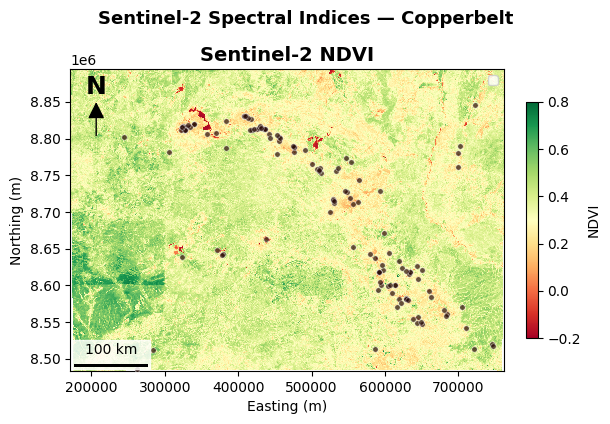

In [24]:
n_plots = len(spectral_indices)
fig, axes = plt.subplots(1, n_plots, figsize=(6 * n_plots, 6), constrained_layout=True)
if n_plots == 1:
    axes = [axes]

cmaps   = {"ndvi": "RdYlGn", "nbr": "RdBu", "ndwi": "Blues"}
vlims   = {"ndvi": (-0.2, 0.8), "nbr": (-0.5, 0.5), "ndwi": (-0.5, 0.5)}

for ax, (name, da) in zip(axes, spectral_indices.items()):
    da_plot = downsample_for_plot(da, target_pixels=1000)
    vmin, vmax = vlims.get(name, (-1, 1))
    img = da_plot.plot(
        ax=ax, cmap=cmaps.get(name, "viridis"),
        vmin=vmin, vmax=vmax, add_colorbar=True,
        cbar_kwargs={"label": name.upper(), "shrink": 0.4, "extend": "neither"},
    )
    mrds_env.plot(
        ax=ax, color=PALETTE["mine"], markersize=15,
        edgecolor="white", linewidth=0.4, zorder=6, alpha=0.7,
    )
    add_map_furniture(ax, title=f"Sentinel-2 {name.upper()}", gdf_ref=mrds)

fig.suptitle("Sentinel-2 Spectral Indices — Copperbelt", fontsize=13, fontweight="bold", y=0.85)
fig.savefig(MAPS_OUT / "01_spectral_indices.png", dpi=150, bbox_inches="tight")
plt.show()

### MODIS NDVI trend (2010-2025)

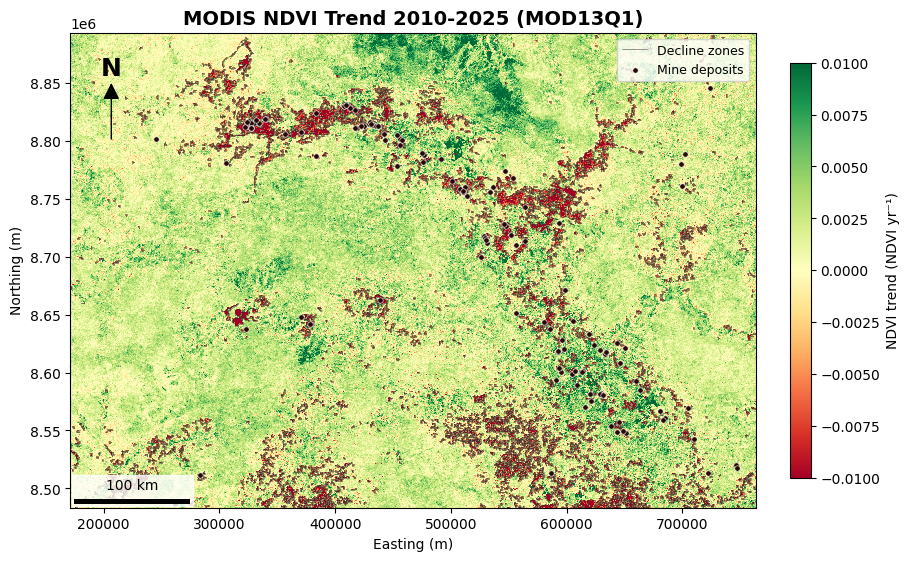

In [26]:
if ndvi_trend is not None:
    fig, ax = plt.subplots(figsize=(9, 7), constrained_layout=True)

    ndvi_trend.plot(
        ax=ax, cmap="RdYlGn",
        vmin=-0.01, vmax=0.01,
        cbar_kwargs={"label": "NDVI trend (NDVI yr⁻¹)", "shrink": 0.6,
                     "extend": "neither"},
    )
    if decline_zones is not None:
        decline_zones.boundary.plot(
            ax=ax, color=PALETTE["degraded"], lw=0.5, alpha=0.7, label="Decline zones",
        )
    mrds_env.plot(
        ax=ax, color=PALETTE["mine"], markersize=15,
        edgecolor="white", linewidth=0.4, zorder=7, label="Mine deposits",
    )
    ax.legend(fontsize=8, loc="upper right")
    add_map_furniture(ax, title="MODIS NDVI Trend 2010-2025 (MOD13Q1)", gdf_ref=mrds)

    fig.savefig(MAPS_OUT / "02_modis_ndvi_trend.png", dpi=150, bbox_inches="tight")
    plt.show()

### Terrain analysis (SRTM)

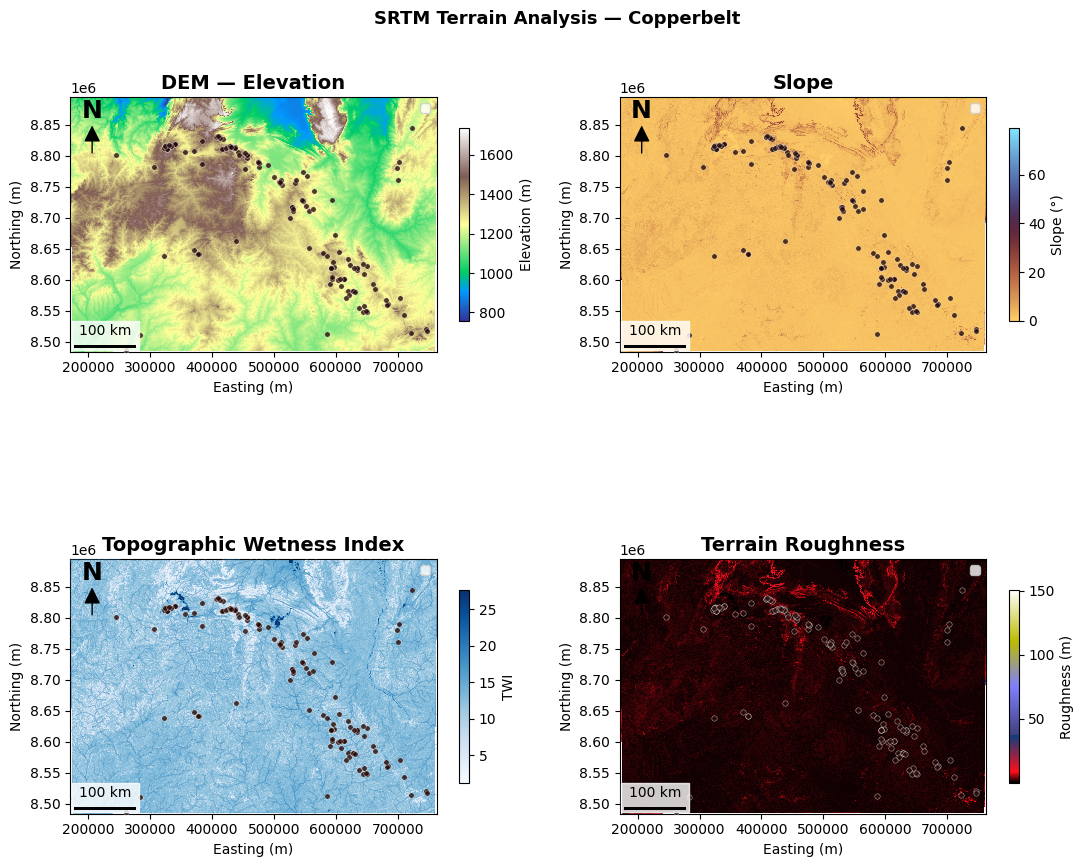

In [27]:
if dem is not None:
    fig, axes = plt.subplots(2, 2, figsize=(13, 11))
    layers = [
        (dem,       "terrain",    "Elevation (m)",   "DEM — Elevation"),
        (slope,     "managua",    "Slope (°)",       "Slope"),
        (twi,       "Blues",      "TWI",             "Topographic Wetness Index"),
        (roughness, "gist_stern", "Roughness (m)",   "Terrain Roughness"),
    ]

    for ax, (da, cmap, cbar_label, title) in zip(axes.flat, layers):
        da_plot = downsample_for_plot(da, target_pixels=1000)
        da_plot.plot(ax=ax, cmap=cmap, cbar_kwargs={"label": cbar_label, "shrink": 0.5})
        mrds_env.plot(
            ax=ax, color=PALETTE["mine"], markersize=15,
            edgecolor="white", linewidth=0.3, zorder=6, alpha=0.8,
        )
        if drainage_network is not None and title == "Topographic Wetness Index":
            drainage_network.plot(ax=ax, color=PALETTE["water"], lw=0.4, alpha=0.6, zorder=5)
        add_map_furniture(ax, title=title, gdf_ref=mrds)

    fig.suptitle("SRTM Terrain Analysis — Copperbelt", fontsize=13, fontweight="bold", y=0.9)
    fig.savefig(MAPS_OUT / "03_terrain_analysis.png", dpi=150, bbox_inches="tight")
    plt.show()

### Composite impact score

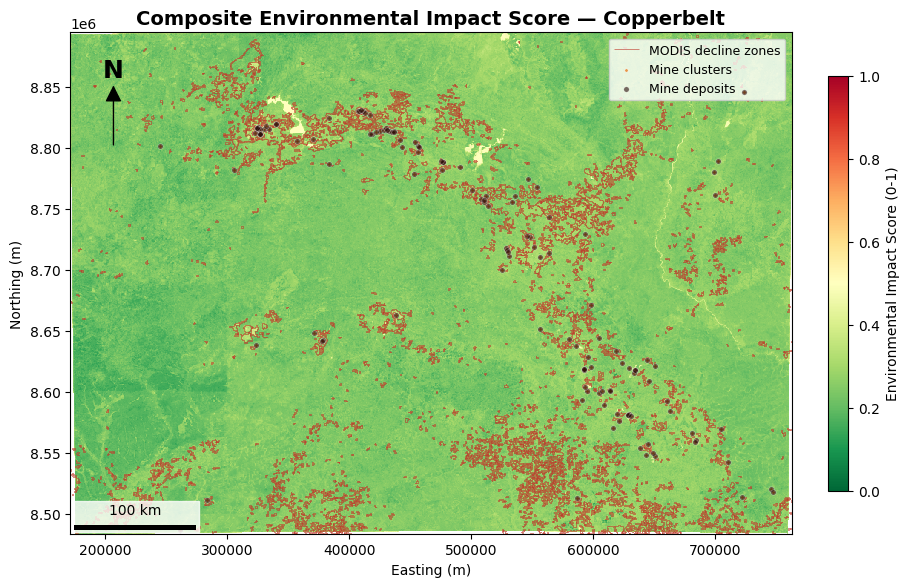

In [25]:
if impact_score is not None:
    fig, ax = plt.subplots(figsize=(9, 7), constrained_layout=True)

    impact_plot = downsample_for_plot(impact_score, target_pixels=1000)

    impact_plot.plot(
        ax=ax, cmap="RdYlGn_r",
        vmin=0, vmax=1,
        cbar_kwargs={"label": "Environmental Impact Score (0-1)", "shrink": 0.6},
    )
    if decline_zones is not None:
        decline_zones.boundary.plot(
            ax=ax, color="#c0392b", lw=0.6, alpha=0.7, label="MODIS decline zones",
        )
    clusters.plot(
        ax=ax, color=PALETTE["cluster"], markersize=6,
        edgecolor="white", linewidth=0.4, zorder=7, alpha=0.8, label="Mine clusters",
    )
    mrds_env.plot(
        ax=ax, color=PALETTE["mine"], markersize=15,
        edgecolor="white", linewidth=0.3, zorder=8, alpha=0.6, label="Mine deposits",
    )
    add_map_furniture(ax, title="Composite Environmental Impact Score — Copperbelt", gdf_ref=mrds)

    fig.savefig(MAPS_OUT / "04_impact_score.png", dpi=150, bbox_inches="tight")
    plt.show()